In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import umap

In [2]:
df = pd.read_csv('../data/children_products/children_product_showcase_full_year_remove_corr.csv')
print(f"Форма датасета: {df.shape}")
df.head()

Форма датасета: (321262, 133)


,phone,СредняяСуммаЗаказов,СредняяМаржаЗаказов,КоличествоТоварныхПозиций,КоличествоЗаказов,ДоляОтменненыхЗаказов,ДоляДоставленныхЗаказов,ОбщееКоличествоТоваров,КоличествоУникальныхТоваров,ОбщаяСуммаУслуг,...,Тип_ИНОЕ,Тип_КГТ,Тип_ОДЕЖДА,Тип_ППКП,МетодДоставки_Групп_Курьерская,МетодДоставки_Групп_Магазины,МетодДоставки_Групп_Пункт выдачи,Гео_МО,Гео_Москва,Гео_Регионы
0,55574851-55555555555176,3585.000000,366.750000,1.000000,1.0,0.0,1.000000,3.0,1.0,0.0,...,0.0,0.000000,0.000000,1.000000,1.0,0.000000,0.000000,0.0,1.0,0.0
1,55575054-56575354545171,1785.714286,198.050000,2.571429,9.0,0.0,0.777778,19.0,17.0,833.0,...,0.0,0.000000,0.277778,0.722222,0.0,1.000000,0.000000,0.0,1.0,0.0
2,55575149-50524951545076,1069.000000,83.970000,1.000000,1.0,0.0,1.000000,1.0,1.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.0,0.0,1.0
3,55575054-49555657564875,13716.000000,1327.620000,2.000000,4.0,0.5,0.250000,2.0,2.0,0.0,...,0.0,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,1.0,0.0,0.0
4,55574857-54575250515477,3067.333333,656.523333,1.000000,3.0,0.0,1.000000,3.0,3.0,0.0,...,0.0,0.333333,0.333333,0.000000,0.0,0.333333,0.666667,1.0,0.0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321262 entries, 0 to 321261
Columns: 133 entries, phone to Гео_Регионы
dtypes: float64(132), object(1)
memory usage: 326.0+ MB


In [4]:
print("Количество пропущенных значений в каждом столбце:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Количество пропущенных значений в каждом столбце:
Series([], dtype: int64)


## Подготовка данных

In [5]:
feature_cols = [col for col in df.columns if col != 'phone']
X = df[feature_cols].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Колонки для профилей кластеров (без категориальных долей)
cols_to_show = [col for col in df.columns
                if not col.startswith('Группа2') and not col.startswith('Группа3')]

print(f"Признаков для моделирования: {len(feature_cols)}")
print(f"Клиентов: {len(X)}")

Признаков для моделирования: 132
Клиентов: 321262


## K-Means: подбор оптимального числа кластеров

In [6]:
k_range = range(2, 11)
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for k in k_range:
    print(f"K-Means k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_scaled, labels))

K-Means k=2...
K-Means k=3...
K-Means k=4...
K-Means k=5...
K-Means k=6...
K-Means k=7...
K-Means k=8...
K-Means k=9...
K-Means k=10...


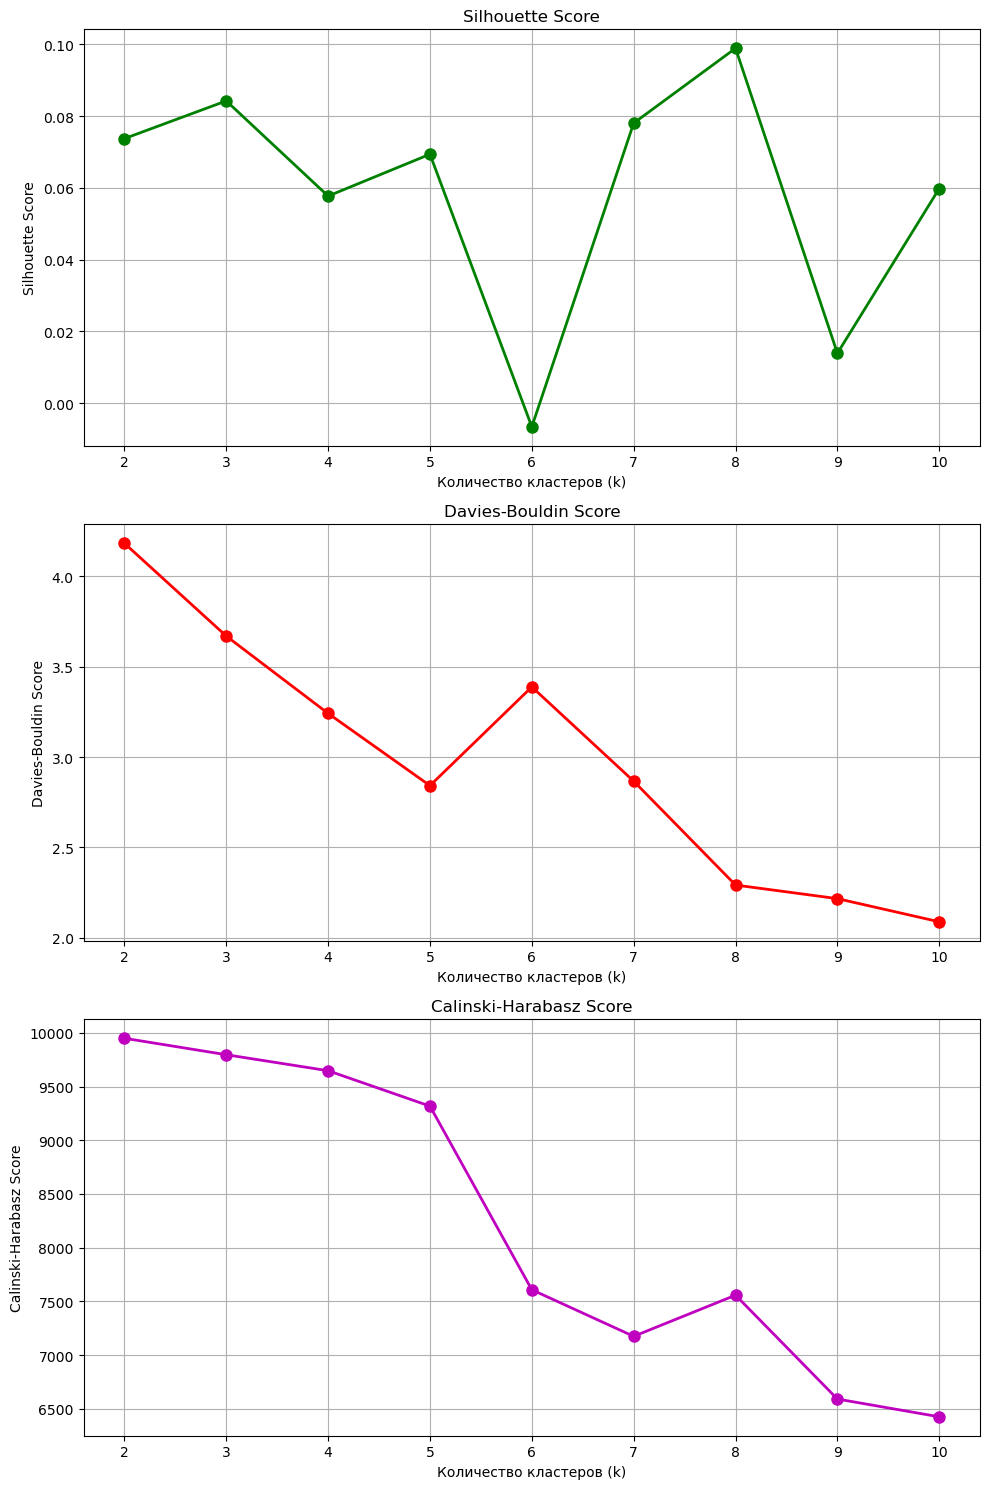

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

axes[0].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0].set_xlabel('Количество кластеров (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score')
axes[0].grid(True)

axes[1].plot(k_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Количество кластеров (k)')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('Davies-Bouldin Score')
axes[1].grid(True)

axes[2].plot(k_range, calinski_harabasz_scores, 'mo-', linewidth=2, markersize=8)
axes[2].set_xlabel('Количество кластеров (k)')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Calinski-Harabasz Score')
axes[2].grid(True)

plt.tight_layout()
plt.show()

## K-Means: финальная модель

In [8]:
optimal_k = 8

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['kmeans_cluster'] = kmeans_labels

print(f"K-Means с k={optimal_k}")
print(f"Распределение по кластерам:")
print(df['kmeans_cluster'].value_counts().sort_index())
print(f"\nМетрики качества:")
print(f"Silhouette Score:        {silhouette_score(X_scaled, kmeans_labels):.4f}")
print(f"Davies-Bouldin Score:    {davies_bouldin_score(X_scaled, kmeans_labels):.4f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz_score(X_scaled, kmeans_labels):.4f}")

K-Means с k=8
Распределение по кластерам:
kmeans_cluster
0    99623
1    14011
2    47784
3     3468
4    31402
5        1
6    50702
7    74271
Name: count, dtype: int64

Метрики качества:
Silhouette Score:        0.0989
Davies-Bouldin Score:    2.2920
Calinski-Harabasz Score: 7557.2359


In [ ]:
# Смотрим на клиента-одиночку
outlier_client = df[df['kmeans_cluster'] == 5]
display(outlier_client)

,phone,СредняяСуммаЗаказов,СредняяМаржаЗаказов,КоличествоТоварныхПозиций,КоличествоЗаказов,ДоляОтменненыхЗаказов,ДоляДоставленныхЗаказов,ОбщееКоличествоТоваров,КоличествоУникальныхТоваров,ОбщаяСуммаУслуг,...,Тип_КГТ,Тип_ОДЕЖДА,Тип_ППКП,МетодДоставки_Групп_Курьерская,МетодДоставки_Групп_Магазины,МетодДоставки_Групп_Пункт выдачи,Гео_МО,Гео_Москва,Гео_Регионы,kmeans_cluster
121763,55574953-50504849555770,2728.0,644.35,2.5,2.0,0.0,1.0,5.0,4.0,98.0,...,0.2,0.0,0.8,0.0,1.0,0.0,0.0,1.0,0.0,5


TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
cluster_counts = df['kmeans_cluster'].value_counts().sort_index()

plt.figure(figsize=(10, 10))
plt.pie(
    cluster_counts,
    labels=[f"Сегмент {i}" for i in cluster_counts.index],
    autopct=lambda p: f'{p:.1f}%\n({int(p*len(df)/100)})',
)
plt.title(f'K-Means: {optimal_k} сегментов клиентов', fontsize=14)
plt.show()

summary_table = pd.DataFrame({
    'Сегмент': [f"Сегмент {i}" for i in cluster_counts.index],
    'Количество клиентов': cluster_counts.values,
    'Доля (%)': (cluster_counts.values / len(df) * 100).round(2)
})
print(tabulate(summary_table, tablefmt='psql', showindex=False))

In [ ]:
cluster_profile = (df[[c for c in cols_to_show if c not in ('phone',)]]
                   .groupby('kmeans_cluster').mean().T)
cluster_profile.style.background_gradient(cmap='coolwarm', axis=1).format("{:.2f}")

## GMM (EM): подбор оптимального числа компонент

In [ ]:
bic_scores = []
aic_scores = []
em_silhouette_scores = []

for k in k_range:
    print(f"GMM k={k}...")
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))
    em_silhouette_scores.append(silhouette_score(X_scaled, labels))

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

axes[0].plot(k_range, em_silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0].set_xlabel('Количество кластеров (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score')
axes[0].grid(True)

axes[1].plot(k_range, bic_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Количество кластеров (k)')
axes[1].set_ylabel('BIC Score')
axes[1].set_title('BIC Score')
axes[1].grid(True)

axes[2].plot(k_range, aic_scores, 'mo-', linewidth=2, markersize=8)
axes[2].set_xlabel('Количество кластеров (k)')
axes[2].set_ylabel('AIC Score')
axes[2].set_title('AIC Score')
axes[2].grid(True)

plt.tight_layout()
plt.show()

## GMM: финальная модель

In [ ]:
optimal_k_em = 5

gmm = GaussianMixture(n_components=optimal_k_em, random_state=42)
em_labels = gmm.fit_predict(X_scaled)
df['em_cluster'] = em_labels

print(f"GMM с k={optimal_k_em}")
print("Распределение по кластерам:")
print(df['em_cluster'].value_counts().sort_index())
print(f"\nМетрики качества:")
print(f"Silhouette Score:        {silhouette_score(X_scaled, em_labels):.4f}")
print(f"Davies-Bouldin Score:    {davies_bouldin_score(X_scaled, em_labels):.4f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz_score(X_scaled, em_labels):.4f}")

In [ ]:
cluster_counts = df['em_cluster'].value_counts().sort_index()

plt.figure(figsize=(10, 10))
plt.pie(
    cluster_counts,
    labels=[f"Сегмент {i}" for i in cluster_counts.index],
    autopct=lambda p: f'{p:.1f}%\n({int(p*len(df)/100)})',
)
plt.title(f'GMM: {optimal_k_em} сегментов клиентов', fontsize=14)
plt.show()

summary_table = pd.DataFrame({
    'Сегмент': [f"Сегмент {i}" for i in cluster_counts.index],
    'Количество клиентов': cluster_counts.values,
    'Доля (%)': (cluster_counts.values / len(df) * 100).round(2)
})
print(tabulate(summary_table, tablefmt='psql', showindex=False))

In [ ]:
cluster_profile = (df[[c for c in cols_to_show if c not in ('phone', 'kmeans_cluster')]]
                   .groupby('em_cluster').mean().T)
cluster_profile.style.background_gradient(cmap='coolwarm', axis=1).format("{:.2f}")

## HDBSCAN

In [ ]:
hdbscan_model = HDBSCAN(
    min_cluster_size=2000,
    min_samples=10,
    metric='euclidean',
    n_jobs=-1
)

hdbscan_labels = hdbscan_model.fit_predict(X_scaled)
df['hdbscan_cluster'] = hdbscan_labels

n_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise = (hdbscan_labels == -1).sum()
print(f"Кластеров: {n_clusters}, шум: {n_noise} ({n_noise/len(df)*100:.1f}%)")
print(df['hdbscan_cluster'].value_counts().sort_index())

In [ ]:
cluster_counts = df['hdbscan_cluster'].value_counts().sort_index()

plt.figure(figsize=(10, 10))
plt.pie(
    cluster_counts,
    labels=[f"Сегмент {i}" if i != -1 else "Шум" for i in cluster_counts.index],
    autopct=lambda p: f'{p:.1f}%\n({int(p*len(df)/100)})',
)
plt.title('HDBSCAN: сегменты клиентов', fontsize=14)
plt.show()

summary_table = pd.DataFrame({
    'Сегмент': [f"Сегмент {i}" if i != -1 else "Шум" for i in cluster_counts.index],
    'Количество клиентов': cluster_counts.values,
    'Доля (%)': (cluster_counts.values / len(df) * 100).round(2)
})
print(tabulate(summary_table, tablefmt='psql', showindex=False))

## Визуализация: PCA + UMAP

In [ ]:
print("Вычисление PCA...")
X_pca = PCA(n_components=2).fit_transform(X_scaled)

print("Вычисление UMAP...")
X_umap = umap.UMAP(n_neighbors=50, random_state=42).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['kmeans_cluster'], cmap='tab10', s=1, alpha=0.5)
axes[0].set_title(f'K-Means k={optimal_k} (PCA)')
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df['em_cluster'], cmap='tab10', s=1, alpha=0.5)
axes[1].set_title(f'GMM k={optimal_k_em} (PCA)')
plt.colorbar(sc1, ax=axes[1])

sc2 = axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=df['hdbscan_cluster'], cmap='tab10', s=1, alpha=0.5)
axes[2].set_title('HDBSCAN (UMAP)')
plt.colorbar(sc2, ax=axes[2])

plt.tight_layout()
plt.show()

## Сохранение результатов

In [ ]:
output_path = '../data/children_products/children_product_segments_full_year.csv'
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Сохранено: {df.shape[0]} клиентов, {df.shape[1]} колонок")
print(f"Колонки кластеров: kmeans_cluster, em_cluster, hdbscan_cluster")